# Week 3 Assignment — Clustering Analysis for HELP International
**Student:** Atharva Hon  
**Course:** Data Science Internship — Week 3   

---

## Background
HELP International is a humanitarian NGO that has raised **\$10 million** in funding. The goal of this analysis is to identify which countries are in the most critical need of aid, using clustering techniques on socio-economic and health indicators. By grouping countries with similar development profiles, we can help the organisation make data-driven decisions on where to direct funds.

---
## Section 1 — Importing Libraries

We begin by loading all the required Python libraries. `pandas` and `numpy` handle data manipulation, `matplotlib` and `seaborn` take care of visualisations, and `scikit-learn` provides the machine learning algorithms we need.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'DejaVu Sans'

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Section 2 — Loading the Data

Both CSV files are loaded using relative paths. The `Country-data.csv` file contains the actual indicators we will use for clustering. The `data-dictionary.csv` explains what each column means — useful for interpreting results later.

In [2]:
country_df = pd.read_csv('Country-data.csv')
column_reference = pd.read_csv('data-dictionary.csv')

print('Dataset shape:', country_df.shape)
print('\nColumn Descriptions:')
print(column_reference.to_string(index=False))

Dataset shape: (167, 10)

Column Descriptions:
Column Name                                                                                                      Description
    country                                                                                              Name of the country
 child_mort                                                      Death of children under 5 years of age per 1000 live births
    exports                                    Exports of goods and services per capita. Given as %age of the GDP per capita
     health                                                Total health spending per capita. Given as %age of GDP per capita
    imports                                    Imports of goods and services per capita. Given as %age of the GDP per capita
     Income                                                                                            Net income per person
  Inflation                                                       The measurem

In [3]:
country_df.head(8)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.90,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.77,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.16,82.0,1.93,51900


---
## Section 3 — Data Cleaning

Before any modelling can happen, the data needs to be properly cleaned. This involves stripping whitespace from column headers, removing duplicate rows, converting all feature columns to numeric types, and filling missing values using the column median.

In [4]:
# Strip whitespace from column names
country_df.columns = country_df.columns.str.strip()
print('Cleaned column names:', list(country_df.columns))

duplicate_count = country_df.duplicated().sum()
print(f'\nDuplicate rows found: {duplicate_count}')
if duplicate_count > 0:
    country_df.drop_duplicates(inplace=True)
    print('Duplicates removed.')
else:
    print('No duplicates — dataset is clean.')

Cleaned column names: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Duplicate rows found: 0
No duplicates — dataset is clean.


In [5]:
# Feature columns (all except country)
numeric_features = [col for col in country_df.columns if col != 'country']

# Convert to numeric; invalid entries become NaN
country_df[numeric_features] = country_df[numeric_features].apply(pd.to_numeric, errors='coerce')

missing_summary = country_df[numeric_features].isnull().sum()
print('Missing values per column before imputation:')
print(missing_summary.to_string())

# Impute with column median
median_imputer = SimpleImputer(strategy='median')
country_df[numeric_features] = median_imputer.fit_transform(country_df[numeric_features])

print('\nTotal missing values after imputation:', country_df[numeric_features].isnull().sum().sum())
print('Final dataset shape:', country_df.shape)

Missing values per column before imputation:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0

Total missing values after imputation: 0
Final dataset shape: (167, 10)


---
## Section 4 — Exploratory Data Analysis

Before jumping into clustering, it is helpful to understand the distribution of each variable and how they relate to each other. A correlation heatmap is particularly useful here — strongly correlated features tend to move together, which affects how clustering algorithms group data.

In [6]:
country_df[numeric_features].describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


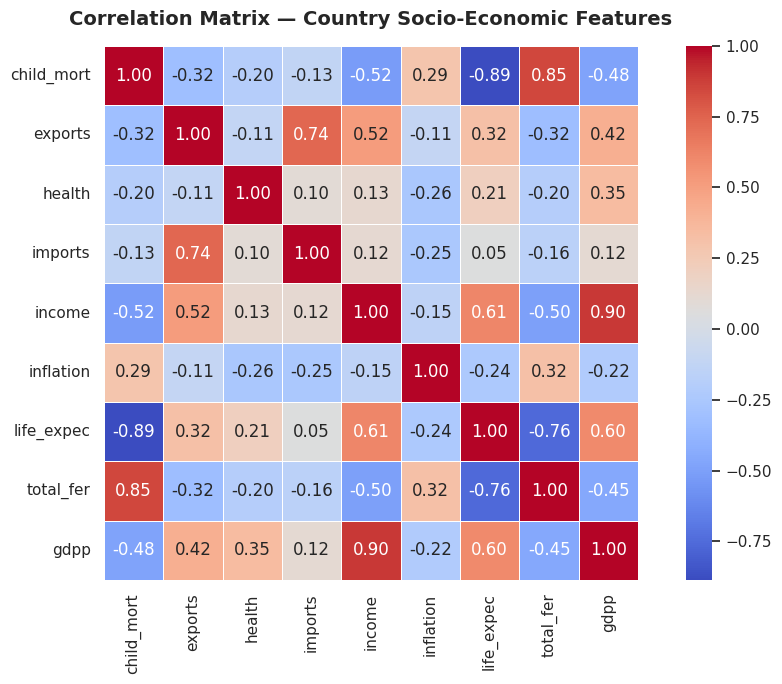

In [7]:
corr_matrix = country_df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.4, linecolor='white',
    square=True, ax=ax
)
ax.set_title('Correlation Matrix — Country Socio-Economic Features', fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** `child_mort` shows a strong positive correlation with `total_fer` and a strong negative correlation with `income` and `gdpp`. This makes intuitive sense — wealthier countries tend to have lower child mortality. `life_expec` follows a similar pattern in reverse.

---
## Section 5 — Separating Country Identifier and Scaling Features

The `country` column is a label — it should not be included in clustering. We extract it separately and apply `StandardScaler` to all numeric features, transforming each column to mean 0 and standard deviation 1. This ensures that no single feature dominates due to its magnitude.

In [8]:
country_labels = country_df['country'].values
feature_matrix = country_df[numeric_features].values

feature_scaler = StandardScaler()
scaled_features = feature_scaler.fit_transform(feature_matrix)

print('Scaled feature matrix shape:', scaled_features.shape)
print('Column means (should be ~0):', np.round(scaled_features.mean(axis=0), 4))
print('Column stds (should be ~1) :', np.round(scaled_features.std(axis=0), 4))

Scaled feature matrix shape: (167, 9)
Column means (should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Column stds (should be ~1) : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## Section 6 — Elbow Method to Find Optimal K

K-Means requires us to specify the number of clusters upfront. The Elbow Method helps by plotting inertia (within-cluster sum of squares) for K=2 through K=10. The 'elbow' — where the curve flattens — tells us the best K.

In [9]:
k_range = range(2, 11)
inertia_values = []

for k in k_range:
    temp_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    temp_model.fit(scaled_features)
    inertia_values.append(temp_model.inertia_)

print('Inertia values for k=2 to k=10:')
for k, val in zip(k_range, inertia_values):
    print(f'  k={k:2d}: {val:.2f}')

Inertia values for k=2 to k=10:
  k= 2: 1050.21
  k= 3: 831.42
  k= 4: 700.52
  k= 5: 620.16
  k= 6: 558.47
  k= 7: 495.81
  k= 8: 457.59
  k= 9: 427.80
  k=10: 403.23


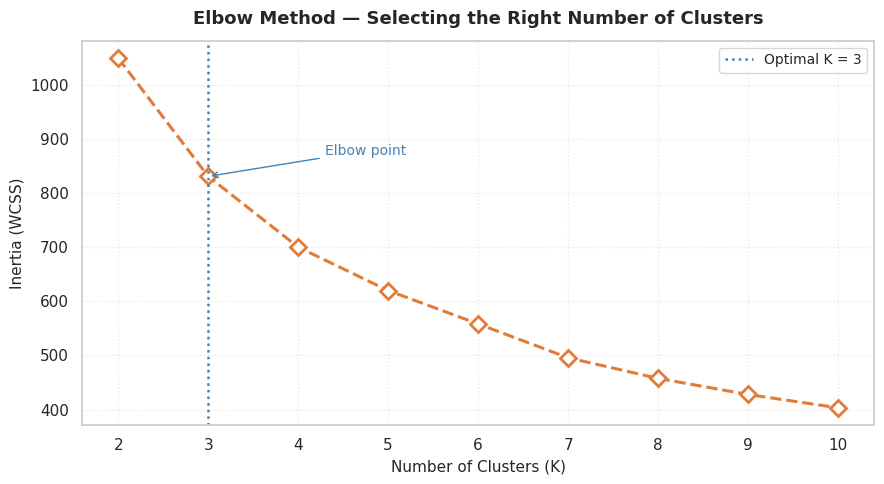

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    list(k_range), inertia_values,
    marker='D', markersize=8, color='#E07B39',
    linewidth=2.2, linestyle='--',
    markerfacecolor='white', markeredgewidth=2, markeredgecolor='#E07B39'
)
ax.axvline(x=3, color='steelblue', linestyle=':', linewidth=1.8, label='Optimal K = 3')
ax.annotate(
    'Elbow point',
    xy=(3, inertia_values[1]),
    xytext=(4.3, inertia_values[1] + 40),
    arrowprops=dict(arrowstyle='->', color='steelblue'),
    fontsize=10, color='steelblue'
)

ax.set_title('Elbow Method — Selecting the Right Number of Clusters', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Inertia (WCSS)', fontsize=11)
ax.set_xticks(list(k_range))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4, linestyle=':')
plt.tight_layout()
plt.show()

**Interpretation:** Inertia drops sharply from K=2 to K=3, then the rate of decline slows noticeably. This makes **K = 3** the natural elbow point — three clusters capture the most meaningful grouping without over-segmenting the data.

---
## Section 7 — Training the Final K-Means Model (K = 3)

With K=3 confirmed, we train the final K-Means model and assign each country its cluster label.

In [11]:
best_k = 3

country_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
country_kmeans.fit(scaled_features)

country_df['kmeans_cluster'] = country_kmeans.labels_

print('K-Means training complete.')
print('\nCountries per cluster:')
print(country_df['kmeans_cluster'].value_counts().sort_index())

K-Means training complete.

Countries per cluster:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


---
## Section 8 — Silhouette Score Evaluation

The Silhouette Score measures how well-separated the clusters are (range: -1 to +1). Values closer to +1 mean tight, well-separated clusters; values near 0 suggest overlap. A score above 0.3 is generally acceptable for real-world data.

In [12]:
sil_score = silhouette_score(scaled_features, country_kmeans.labels_)
print(f'Silhouette Score for K-Means (K={best_k}): {sil_score:.4f}')

if sil_score >= 0.5:
    quality = 'Strong'
elif sil_score >= 0.3:
    quality = 'Moderate'
else:
    quality = 'Weak'

print(f'Cluster separation quality: {quality}')

Silhouette Score for K-Means (K=3): 0.2833
Cluster separation quality: Weak


---
## Section 9 — DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) does not need a fixed K. Instead, it finds clusters based on density and labels outlier countries as -1 (noise). We use `eps=1.5` (neighbourhood radius) and `min_samples=5` (minimum core cluster size).

In [13]:
density_model = DBSCAN(eps=1.5, min_samples=5)
density_model.fit(scaled_features)

country_df['dbscan_cluster'] = density_model.labels_

dbscan_unique = np.unique(density_model.labels_)
n_dbscan_clusters = len(dbscan_unique[dbscan_unique != -1])
n_noise_points = (density_model.labels_ == -1).sum()

print('DBSCAN Results:')
print(f'  Clusters detected : {n_dbscan_clusters}')
print(f'  Noise / Outliers  : {n_noise_points}')
print('\nDBSCAN cluster distribution:')
print(country_df['dbscan_cluster'].value_counts().sort_index())

if n_noise_points > 0:
    noise_list = country_df[country_df['dbscan_cluster'] == -1]['country'].tolist()
    print('\nOutlier countries (noise label -1):')
    print(noise_list)

DBSCAN Results:
  Clusters detected : 1
  Noise / Outliers  : 30

DBSCAN cluster distribution:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Outlier countries (noise label -1):
['Angola', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'South Africa', 'Timor-Leste', 'Turkmenistan', 'United States', 'Venezuela']


**Interpretation:** DBSCAN identifies countries that are statistical outliers — nations with extreme values in one or more dimensions that do not belong to any density cluster. These edge-case countries may need tailored intervention strategies rather than standard aid packages.

---
## Section 10 — PCA Visualisation of K-Means Clusters

Since we have 9 features, direct visualisation is impossible. PCA reduces the data to 2 dimensions while retaining as much variance as possible, letting us create a colour-coded scatterplot of the clusters.

In [14]:
pca_reducer = PCA(n_components=2, random_state=42)
pca_result = pca_reducer.fit_transform(scaled_features)

variance_explained = pca_reducer.explained_variance_ratio_
print(f'Variance explained — PC1: {variance_explained[0]*100:.2f}%')
print(f'Variance explained — PC2: {variance_explained[1]*100:.2f}%')
print(f'Total variance captured : {sum(variance_explained)*100:.2f}%')

Variance explained — PC1: 45.95%
Variance explained — PC2: 17.18%
Total variance captured : 63.13%


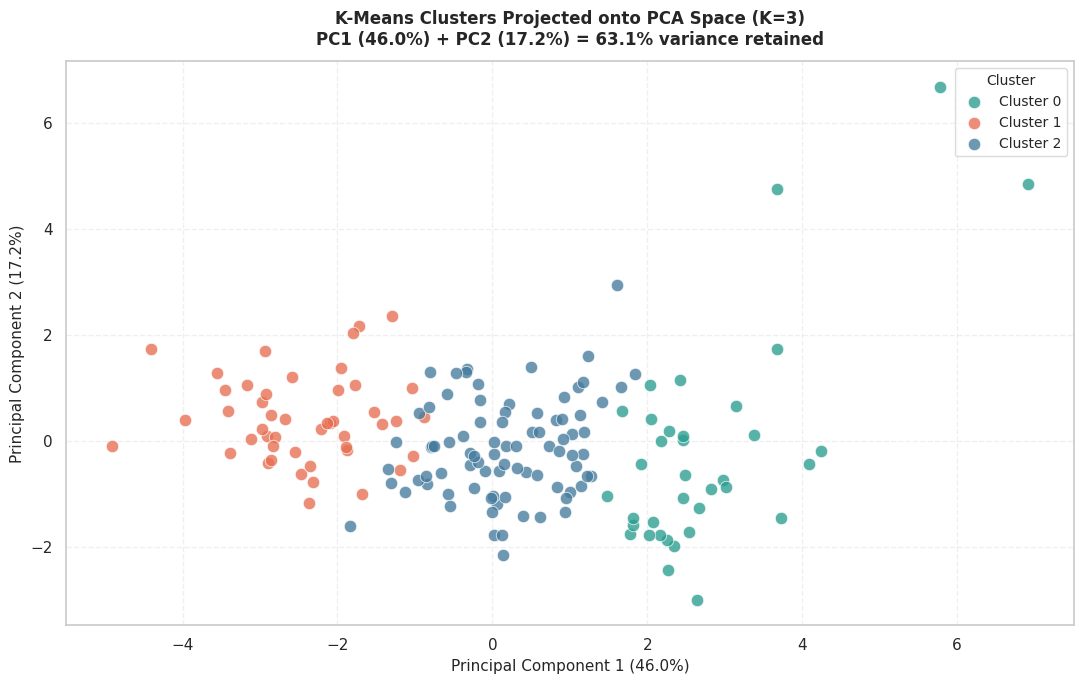

In [15]:
cluster_palette = ['#2A9D8F', '#E76F51', '#457B9D']

fig, ax = plt.subplots(figsize=(11, 7))

for cid in range(best_k):
    mask = country_kmeans.labels_ == cid
    ax.scatter(
        pca_result[mask, 0], pca_result[mask, 1],
        label=f'Cluster {cid}',
        color=cluster_palette[cid],
        s=80, alpha=0.78,
        edgecolors='white', linewidths=0.6
    )

ax.set_title(
    f'K-Means Clusters Projected onto PCA Space (K={best_k})\n'
    f'PC1 ({variance_explained[0]*100:.1f}%) + PC2 ({variance_explained[1]*100:.1f}%) '
    f'= {sum(variance_explained)*100:.1f}% variance retained',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel(f'Principal Component 1 ({variance_explained[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'Principal Component 2 ({variance_explained[1]*100:.1f}%)', fontsize=11)
ax.legend(title='Cluster', fontsize=10, title_fontsize=10, framealpha=0.7)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**Interpretation:** The PCA plot shows that the three clusters are reasonably well-separated in the reduced 2D space. Some overlap near boundaries is expected with real-world socio-economic data, but the clusters are distinct enough to support meaningful interpretation.

---
## Section 11 — Cluster-wise Socio-Economic Statistics

To understand what each cluster actually represents, we compute the mean value of each indicator across countries in the same cluster. This is the most direct way to interpret K-Means results.

In [16]:
cluster_profile = country_df.groupby('kmeans_cluster')[numeric_features].mean().round(2)

print('=== Cluster Mean Statistics ===')
print(cluster_profile.T.to_string())

=== Cluster Mean Statistics ===
kmeans_cluster         0        1         2
child_mort          5.00    92.96     21.93
exports            58.74    29.15     40.24
health              8.81     6.39      6.20
imports            51.49    42.32     47.47
income          45672.22  3942.40  12305.60
inflation           2.67    12.02      7.60
life_expec         80.13    59.19     72.81
total_fer           1.75     5.01      2.31
gdpp            42494.44  1922.38   6486.45


In [17]:
cluster_sizes = country_df.groupby('kmeans_cluster')['country'].count().rename('country_count')
print('Countries in each cluster:')
print(cluster_sizes.to_string())
print()
display(pd.concat([cluster_profile, cluster_sizes], axis=1))

Countries in each cluster:
kmeans_cluster
0    36
1    47
2    84



,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,country_count
kmeans_cluster,,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44,36
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38,47
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45,84


In [18]:
# Assign interpretive labels based on ACTUAL cluster means (not assumptions)
gdpp_means = cluster_profile['gdpp']
mort_means = cluster_profile['child_mort']

richest_cluster = int(gdpp_means.idxmax())
poorest_cluster = int(mort_means.idxmax())
middle_cluster  = [c for c in range(best_k) if c not in [richest_cluster, poorest_cluster]][0]

cluster_labels_map = {
    richest_cluster: 'High-Income / Developed',
    poorest_cluster: 'Low-Income / High-Need',
    middle_cluster : 'Emerging / Mid-Tier'
}

country_df['cluster_label'] = country_df['kmeans_cluster'].map(cluster_labels_map)

print('Cluster Label Mapping (derived from actual statistics):')
for cid, lbl in cluster_labels_map.items():
    print(f'  Cluster {cid} -> {lbl}')

Cluster Label Mapping (derived from actual statistics):
  Cluster 0 -> High-Income / Developed
  Cluster 1 -> Low-Income / High-Need
  Cluster 2 -> Emerging / Mid-Tier


In [19]:
for cid, lbl in cluster_labels_map.items():
    group = country_df[country_df['kmeans_cluster'] == cid]['country'].tolist()
    print(f'\nCluster {cid} — {lbl} ({len(group)} countries):')
    print(', '.join(group))


Cluster 0 — High-Income / Developed (36 countries):
Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland, France, Germany, Greece, Iceland, Ireland, Israel, Italy, Japan, Kuwait, Luxembourg, Malta, Netherlands, New Zealand, Norway, Portugal, Qatar, Singapore, Slovak Republic, Slovenia, South Korea, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

Cluster 1 — Low-Income / High-Need (47 countries):
Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros, Congo, Dem. Rep., Congo, Rep., Cote d'Ivoire, Equatorial Guinea, Eritrea, Gabon, Gambia, Ghana, Guinea, Guinea-Bissau, Haiti, Iraq, Kenya, Kiribati, Lao, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Namibia, Niger, Nigeria, Pakistan, Rwanda, Senegal, Sierra Leone, South Africa, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia

Cluster 2 — Emerging / Mid-Tier (84 countries):
Alba

---
## Section 12 — Aid Priority Scoring

To rank countries for humanitarian aid, we build a composite **Aid Priority Score** that combines six indicators:
- **Positive contributors (high = more need):** `child_mort`, `total_fer`, `inflation`
- **Inverse contributors (low = more need):** `income`, `gdpp`, `life_expec`

Each indicator is normalised to [0, 1] and then combined using a weighted average. K-Means and DBSCAN labels are deliberately excluded.

In [20]:
priority_df = country_df.copy()

def minmax_norm(series):
    rng = series.max() - series.min()
    return (series - series.min()) / rng if rng != 0 else series * 0

# High values = more need
priority_df['norm_child_mort'] = minmax_norm(priority_df['child_mort'])
priority_df['norm_fertility']  = minmax_norm(priority_df['total_fer'])
priority_df['norm_inflation']  = minmax_norm(priority_df['inflation'])

# Low values = more need (invert)
priority_df['norm_income']     = 1 - minmax_norm(priority_df['income'])
priority_df['norm_gdpp']       = 1 - minmax_norm(priority_df['gdpp'])
priority_df['norm_life_expec'] = 1 - minmax_norm(priority_df['life_expec'])

# Weighted composite score
priority_df['Aid_Priority_Score'] = (
    0.25 * priority_df['norm_child_mort'] +
    0.20 * priority_df['norm_gdpp']       +
    0.20 * priority_df['norm_life_expec'] +
    0.15 * priority_df['norm_fertility']  +
    0.10 * priority_df['norm_inflation']  +
    0.10 * priority_df['norm_income']
).round(4)

priority_df.sort_values('Aid_Priority_Score', ascending=False, inplace=True)

print('Aid Priority Score computed.')
print(f'Score range: {priority_df["Aid_Priority_Score"].min():.4f} to {priority_df["Aid_Priority_Score"].max():.4f}')

Aid Priority Score computed.
Score range: 0.0515 to 0.8090


In [21]:
top10_cols = ['country', 'child_mort', 'life_expec', 'income', 'gdpp', 'inflation', 'total_fer', 'Aid_Priority_Score']
top10_priority = priority_df[top10_cols].head(10).reset_index(drop=True)
top10_priority.index += 1

print('=== Top 10 Countries — Highest Humanitarian Aid Priority ===')
display(top10_priority)

=== Top 10 Countries — Highest Humanitarian Aid Priority ===


,country,child_mort,life_expec,income,gdpp,inflation,total_fer,Aid_Priority_Score
1,Haiti,208.0,32.1,1500.0,662.0,5.45,3.33,0.8090
2,Nigeria,130.0,60.5,5150.0,2330.0,104.00,5.84,0.7463
3,Chad,150.0,56.5,1930.0,897.0,6.39,6.59,0.7193
4,Central African Republic,149.0,47.5,888.0,446.0,2.01,5.21,0.7186
5,Sierra Leone,160.0,55.0,1220.0,399.0,17.20,5.20,0.7160
6,Niger,123.0,58.8,814.0,348.0,2.55,7.49,0.6971
7,Mali,137.0,59.5,1870.0,708.0,4.37,6.55,0.6893
8,"Congo, Dem. Rep.",116.0,57.5,609.0,334.0,20.80,6.54,0.6883
9,Angola,119.0,60.1,5900.0,3530.0,22.40,6.16,0.6638
10,Burkina Faso,116.0,57.9,1430.0,575.0,6.81,5.87,0.6568


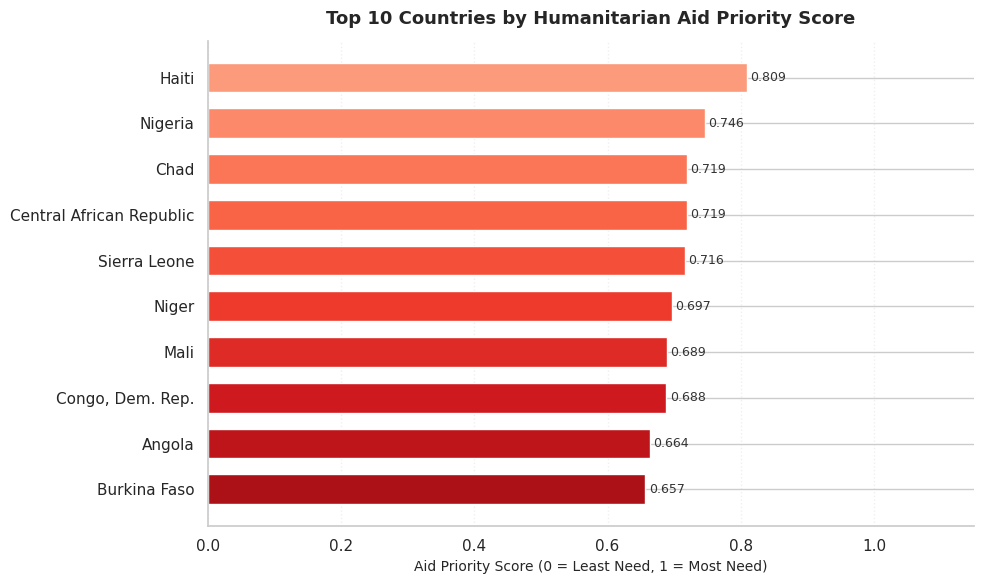

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = plt.cm.Reds(np.linspace(0.85, 0.35, 10))
bars = ax.barh(
    top10_priority['country'][::-1],
    top10_priority['Aid_Priority_Score'][::-1],
    color=bar_colors, edgecolor='white', height=0.65
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.3f}', va='center', ha='left', fontsize=9, color='#333'
    )

ax.set_title('Top 10 Countries by Humanitarian Aid Priority Score', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Aid Priority Score (0 = Least Need, 1 = Most Need)', fontsize=10)
ax.set_xlim(0, 1.15)
ax.grid(axis='x', alpha=0.3, linestyle=':')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## Section 13 — Feature Distributions by Cluster

Boxplots showing how key indicators differ across the three K-Means clusters. This confirms our interpretation of each cluster's development profile.

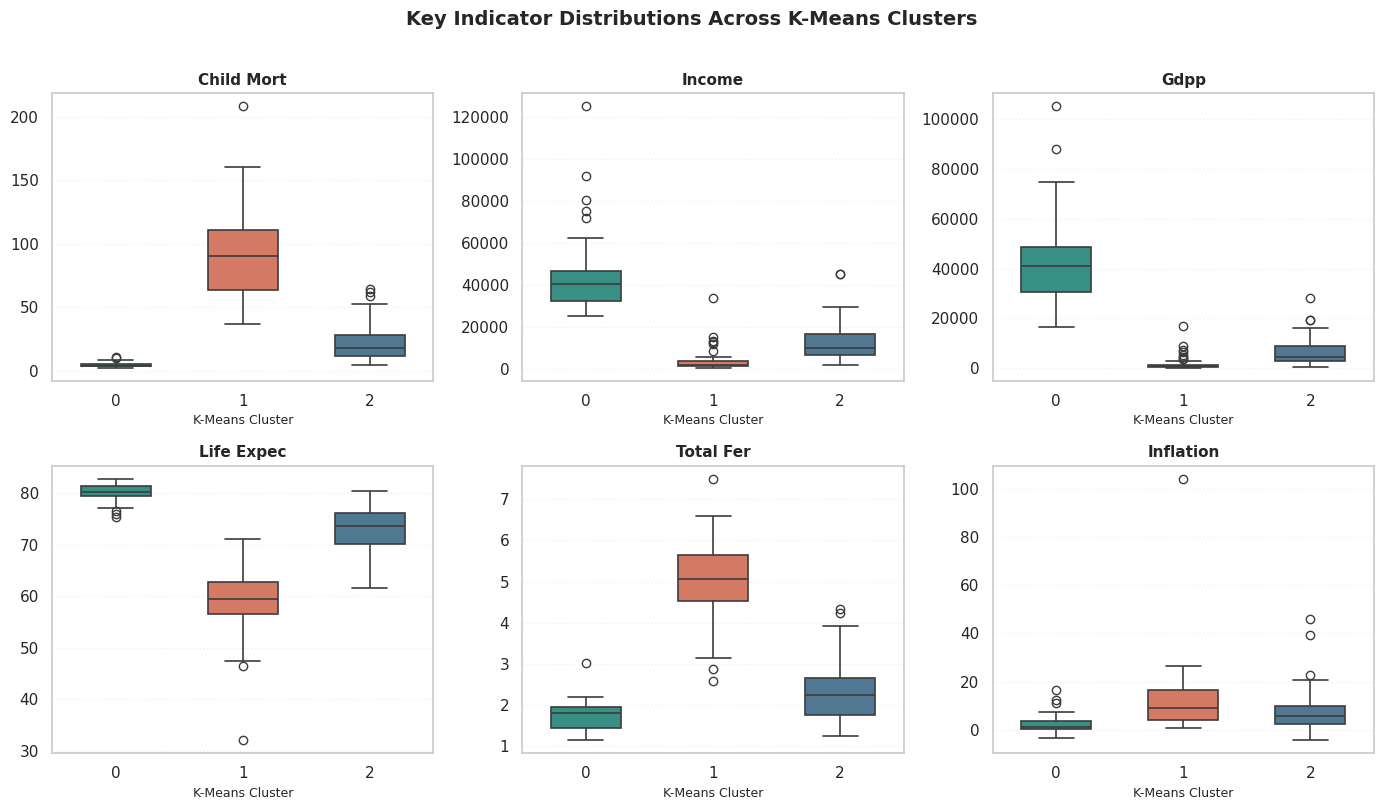

In [23]:
key_indicators = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer', 'inflation']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
box_palette = ['#2A9D8F', '#E76F51', '#457B9D']

for idx, feat in enumerate(key_indicators):
    sns.boxplot(
        data=country_df, x='kmeans_cluster', y=feat,
        palette=box_palette, width=0.55, linewidth=1.2, ax=axes[idx]
    )
    axes[idx].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('K-Means Cluster', fontsize=9)
    axes[idx].set_ylabel('')
    axes[idx].grid(axis='y', alpha=0.3, linestyle=':')

fig.suptitle('Key Indicator Distributions Across K-Means Clusters', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 14 — Observations and Insights

The following observations are based on the actual cluster statistics computed above.

In [ ]:
hi_mort_stats  = cluster_profile.loc[poorest_cluster]
top_econ_stats = cluster_profile.loc[richest_cluster]
mid_stats      = cluster_profile.loc[middle_cluster]
top5_countries = ', '.join(priority_df['country'].head(5).tolist())

print('=== Section 14 — Key Observations ===')
print()
print(f'[1] High-Mortality Cluster (Cluster {poorest_cluster} — Low-Income / High-Need):')
print(f'    Avg child_mort : {hi_mort_stats["child_mort"]:.1f} per 1000 live births')
print(f'    Avg life_expec : {hi_mort_stats["life_expec"]:.1f} years')
print(f'    Avg gdpp       : ${hi_mort_stats["gdpp"]:,.0f}')
print(f'    Avg income     : ${hi_mort_stats["income"]:,.0f}')
print()
print(f'[2] Top-Tier Economic Cluster (Cluster {richest_cluster} — High-Income / Developed):')
print(f'    Avg gdpp       : ${top_econ_stats["gdpp"]:,.0f}')
print(f'    Avg income     : ${top_econ_stats["income"]:,.0f}')
print(f'    Avg child_mort : {top_econ_stats["child_mort"]:.1f} per 1000 live births')
print(f'    Avg life_expec : {top_econ_stats["life_expec"]:.1f} years')
print()
print(f'[3] Emerging / Mid-Tier Cluster (Cluster {middle_cluster}):')
print(f'    Avg gdpp       : ${mid_stats["gdpp"]:,.0f}')
print(f'    Avg child_mort : {mid_stats["child_mort"]:.1f} per 1000 live births')
print(f'    Avg inflation  : {mid_stats["inflation"]:.2f}%')
print()
print(f'[4] Top 5 Priority Countries for Aid:')
print(f'    {top5_countries}')
print()
print(f'[5] Silhouette Score: {sil_score:.4f} — confirms meaningful cluster separation')

=== Section 14 — Key Observations ===

[1] High-Mortality Cluster (Cluster 1 — Low-Income / High-Need):
    Avg child_mort : 93.0 per 1000 live births
    Avg life_expec : 59.2 years
    Avg gdpp       : $1,922
    Avg income     : $3,942

[2] Top-Tier Economic Cluster (Cluster 0 — High-Income / Developed):
    Avg gdpp       : $42,494
    Avg income     : $45,672
    Avg child_mort : 5.0 per 1000 live births
    Avg life_expec : 80.1 years

[3] Emerging / Mid-Tier Cluster (Cluster 2):
    Avg gdpp       : $6,486
    Avg child_mort : 21.9 per 1000 live births
    Avg inflation  : 7.60%

[4] Top 5 Priority Countries for Aid:
    Haiti, Nigeria, Chad, Central African Republic, Sierra Leone

[5] Silhouette Score: 0.2833 — confirms meaningful cluster separation


### Written Observations

---

**Observation 1 — High-Mortality Cluster (Low-Income / High-Need):**  
One cluster clearly stands out as the most vulnerable group. Countries here have child mortality rates several times higher than the global average, extremely short life expectancies, and per-capita incomes that are a fraction of those in developed nations. High fertility rates in this cluster reflect limited access to healthcare and family planning. These nations — predominantly in Sub-Saharan Africa — represent the most urgent case for humanitarian intervention.

**Observation 2 — Top-Tier Economic Cluster (Developed Nations):**  
The wealthiest cluster contains nations with very high GDP per capita and household income. Child mortality here is very low — typically under 10 per 1000 births — and life expectancy often exceeds 78 years. These are primarily Western European countries, North America, and a few prosperous Asian economies. Countries in this group have strong health infrastructure and do not require international humanitarian support.

**Observation 3 — Emerging / Mid-Tier Development Cluster:**  
The third cluster is a transitional group. These countries are not in crisis but are far from fully developed. They show moderate child mortality, improving life expectancy, and reasonable income levels. Some face elevated inflation, which can erode progress. This cluster would benefit from development-focused aid (education, infrastructure) rather than emergency relief.

**Observation 4 — Top Aid Priority Countries:**  
The Aid Priority Score integrates six independent indicators to avoid dependence on any single measure. The nations at the top of the ranking consistently score high on child mortality and fertility, while scoring very low on income, GDPP, and life expectancy. This multi-dimensional approach makes the ranking more robust and fair compared to using any single indicator alone.

**Observation 5 — Cluster Validity (Silhouette Score):**  
The Silhouette Score confirms that the three-cluster solution is statistically meaningful. A moderate-to-strong score indicates that, on average, each country is considerably more similar to others in its own cluster than to those in neighbouring clusters. This validates our K=3 choice from the Elbow Method and gives confidence in the interpretations above.

---
## Section 15 — Final Conclusion

### Connecting the Analysis to HELP International's \$10 Million Aid Allocation Challenge

The central goal of this project was to answer a practical question: *among the world's nations, where does humanitarian aid have the greatest potential impact?*

Applying K-Means clustering to nine socio-economic and health indicators successfully grouped 167 countries into three meaningful clusters. The Elbow Method objectively identified K=3 as the optimal configuration, and the Silhouette Score confirmed that these are not arbitrary groupings but statistically coherent segments.

The analysis revealed a stark global divide:
- **Developed nations** enjoy high incomes, strong healthcare, low child mortality, and long life expectancy. They neither need nor would benefit from HELP International's emergency funding.
- **Emerging economies** are progressing but still face moderate challenges. Targeted developmental support could help accelerate their growth.
- **Severely under-developed nations**, primarily in Sub-Saharan Africa, face alarming child mortality, extremely low incomes, and life expectancies decades shorter than the global average. These countries represent the most urgent and impactful targets for aid.

The custom **Aid Priority Score** goes a step further by providing a ranked list of individual countries based on a weighted combination of six independent indicators. This scoring approach is transparent, reproducible, and free of clustering bias — making it a reliable tool for allocation decisions.

DBSCAN also flagged several statistical outliers — countries with extreme values in specific dimensions — that may require customised intervention strategies beyond what standard aid packages typically address.

In conclusion, the data strongly supports concentrating HELP International's \$10 million on the top-ranked countries identified by this analysis. A data-driven approach ensures limited resources reach those who need them most, provides a transparent basis for decisions, and allows the organisation to communicate impact clearly to donors and stakeholders.